# Spatially-informed Bivariate Metrics

This tutorial provides an overview of the local scores implemented in LIANA+. These scores are used to identify spatially co-expressed ligand-receptor pairs. However, there also applicable to other types of spatially-informed bivariate analyses.

It provides brief explanations of the mathematical formulations of the scores; these include adaptation of bivariate Moran's R, Pearson correlation, Spearman correlation, weighted Jaccard similarity, and Cosine similarity. The tutorial also showcases interaction categories (masks) and significance testing. 

## Environement Setup

In [1]:
import pandas as pd
import scanpy as sc
import decoupler as dc
import liana as li
from matplotlib import pyplot as plt

# embed figures as JPEG to keep the notebook small
%config InlineBackend.figure_formats = ['jpeg']
plt.rcParams['figure.dpi'] = 75

from mudata import MuData

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and Normalize Data

To showcase LIANA's local functions, we will use an ischemic 10X Visium spatial slide from [Kuppe et al., 2022](https://www.nature.com/articles/s41586-022-05060-x). It is a tissue sample obtained from a patient with myocardial infarction, focusing on the ischemic zone of the heart tissue. 

The slide provides spatially-resolved information about the cellular composition and gene expression patterns within the tissue.

In [2]:
adata = li.ds.kuppe_2022()
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [3]:
adata.obs.head()

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,mt_frac,celltype_niche,molecular_niche
AAACAAGTATCTCCCA-1,1,50,102,Visium_19_CK297,3125,8.047510,7194.0,8.881142,24.770642,31.387267,39.797053,54.503753,0.085630,ctniche_1,molniche_9
AAACAATCTACTAGCA-1,1,3,43,Visium_19_CK297,3656,8.204398,10674.0,9.275660,35.956530,42.167885,49.456624,61.045531,0.033275,ctniche_5,molniche_3
AAACACCAATAACTGC-1,1,59,19,Visium_19_CK297,3013,8.011023,7339.0,8.901094,33.247036,39.910069,47.227143,59.326884,0.029139,ctniche_5,molniche_3
AAACAGAGCGACTCCT-1,1,14,94,Visium_19_CK297,4774,8.471149,14235.0,9.563529,22.739726,29.884089,37.850369,51.099403,0.149194,ctniche_7,molniche_2
AAACAGCTTTCAGAAG-1,1,43,9,Visium_19_CK297,2734,7.913887,6920.0,8.842316,35.664740,42.268786,50.000000,62.384393,0.025601,ctniche_5,molniche_3


Spot clusters

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/1879330998.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.


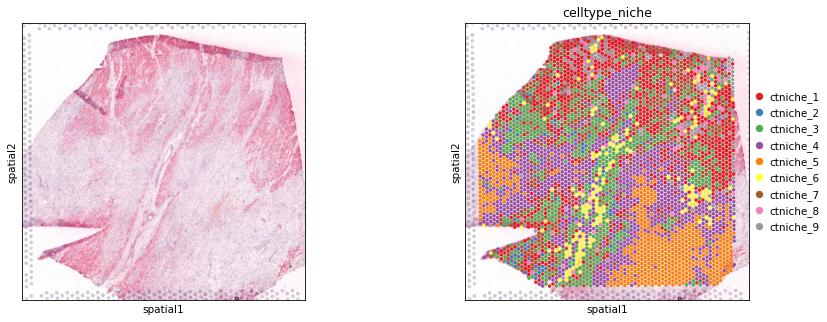

In [4]:
sc.pl.spatial(adata, color=[None, 'celltype_niche'], size=1.3, palette='Set1')

## Background

Here, we will demonstrate how to use the spatially-informed bivariate metrics to assess the spatial relationship between two variables. Specifically, we focus on local bivariate similarity metrics. In contrast to other spatial Methods, including [Misty](https://liana-py.readthedocs.io/en/latest/notebooks/misty.html); focusing on local spatial relationships enables us to pinpoint the exact location of spatial relationships, and to identify spatial relationships that might occur only in a specific sub-region of our samples.

Following the initial concept of LIANA, and inspired by [scHOT](https://www.nature.com/articles/s41592-020-0885-x), we have natively re-implemented **6** local bivariate metrics, including scHOT's (default) masked Spearman & [SpatialDM's](https://www.biorxiv.org/content/10.1101/2022.08.19.504616v1.full) local Moran's R.

As part of the [LIANA+ manuscript](https://www.biorxiv.org/content/10.1101/2023.08.19.553863v1.full), we performed two distinct tasks to evaluate the ability of these metrics to preserve biological information, and saw that on average when used to identify local ligand-receptor relationships, spatially-weighted Cosine similarity did best. Thus, we will focus on it throughout this tutorial. However, we expect that other scoring functions might be better suited for other tasks, e.g. Spatially-weighted Jaccard Similarity should be well suited for categorical data; thus we encourage you to explore them.

### Available Local Functions

In [5]:
li.mt.bivariate.show_functions()

,name,metadata,reference
0,pearson,weighted Pearson correlation coefficient,NaN
1,spearman,weighted Spearman correlation coefficient,NaN
2,cosine,weighted Cosine similarity,NaN
3,jaccard,weighted Jaccard similarity,NaN
4,product,simple weighted product,If vars are z-scaled = Lee's static (Lee 2021;...
5,norm_product,normalized weighted product,NaN
6,morans,Moran's R,"Li, Z., Wang, T., Liu, P. and Huang, Y., 2022...."
7,masked_spearman,masked & weighted Spearman correlation,"Ghazanfar, S., Lin, Y., Su, X., Lin, D.M., Pat..."


### How do they work?

The local functions work are quite simple, as they are simply weighted versions of well-known similarity metrics. For example, the spatially-weighted version of Cosine similarity is defined as:

$$ \text{wCosine}_i = \frac{\sum_{j=1}^n w_{ij} x_j y_j}{\sqrt{\sum_{j=1}^n w_{ij} x_j^2} \sqrt{\sum_{j=1}^n w_{ij} y_j^2}}$$

where for each spot **i**, we perform summation over all spots **n**, where **w**​ represents the spatial connectivity weights from spot **i** to every other spot **j**;  for variables  **x** and **y**.

### Spatial Connectivity

The way that spatially-informed methods usually work is by making use of weights based on the proximity (or spatial connectivity) between spots/cells.
These spatial connectivities are then used to calculate the metric of interest, e.g. Cosine similarity, in a spatially-informed manner.

The spatial weights in LIANA+ are by default defined as a family of radial kernels that use the inverse Euclidean distance between cells/spots to bind the weights between 0 and 1, with spots that are closest having the highest spatial connectivity to one another (1), while those that are thought to be too far to be in contact are assigned 0.

Key parameters of spatial_neighbors include:
- `bandwidth` controls the radius of the spatial connectivities where higher values will result in a broader area being considered (controls the radius relative to the coordinates stored in `adata.obsm['spatial']`)
- `cutoff` controls the minimum value that will be considered to have a spatial relationship (anything lower than the `cutoff` is set to 0).
- `kernel` controls the distribution (shape) of the weights ('gaussian' by default)
- `set_diag` sets the diagonal (i.e. the weight for each spot to itself) to 1 if True. **NOTE**: Here we set it to True as we expect many cells to be neighbors of themselves within a visium spot

As choosing an optimal bandwidith can be tricky, we provide the ``query_bandwidth`` function which uses a set of coordinates to provide an estimate of how many cell or spot neighbors are being considered for each spot over a range of bandwidths. 

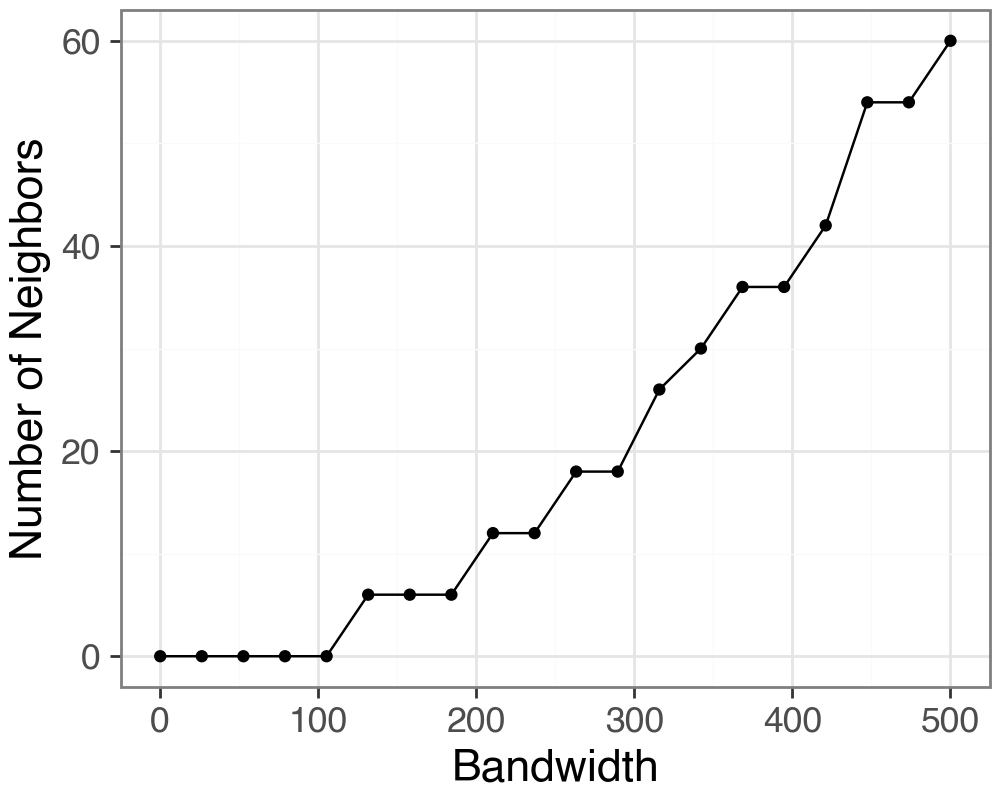

In [6]:
plot, _ = li.pp.query_bandwidth(coordinates=adata.obsm['spatial'], start=0, end=500, interval_n=20, figure_size=(5,4))
plot

Here, we can see that a bandwidth of 150-200 (pixels) roughly includes 6 neighbours i.e. the first ring of neighbours in the hexagonal grid of 10x Visium. So, we will build the spatial graph with a bandwidth of 200.

In [7]:
li.pp.spatial_neighbors(adata, bandwidth=200, cutoff=0.1, kernel='gaussian', set_diag=True)

Let's visualize the spatial weights for a single spot to all other spots in the dataset:

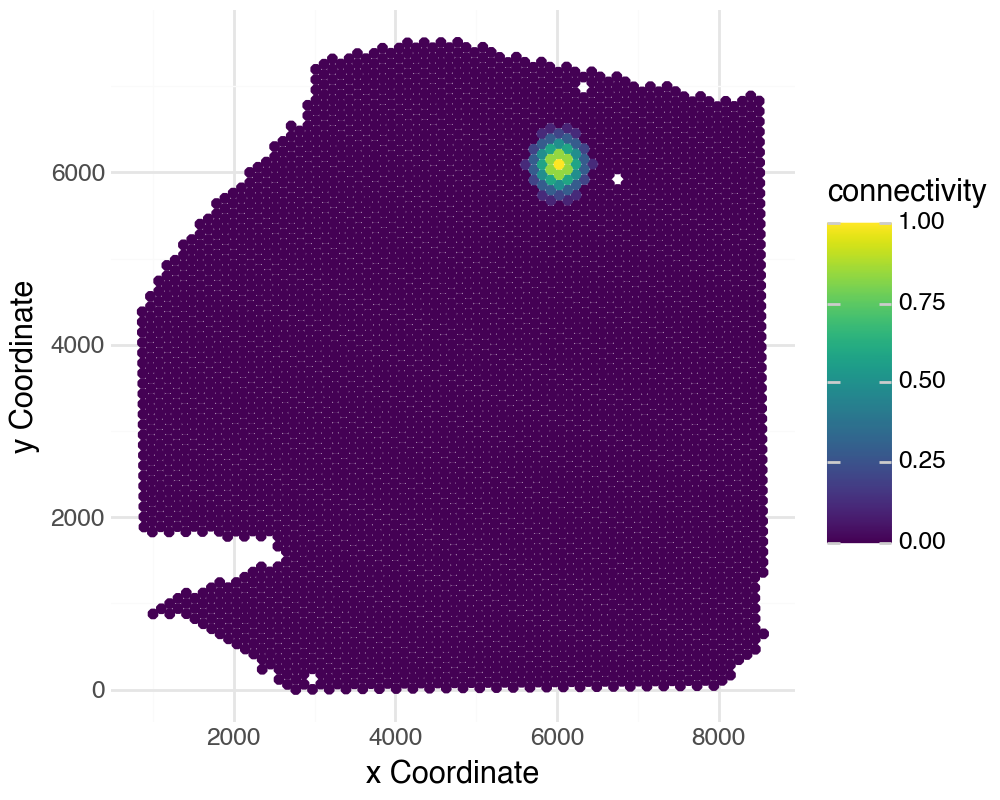

In [8]:
li.pl.connectivity(adata, idx=0, size=1.3, figure_size=(5, 4))

<div class="alert alert-success">

LIANA's connectivities are flexible and can be defined in any way that fits the user. We have thus aligned LIANA's `spatial_neighbors` function to [Squidpy](https://github.com/scverse/squidpy)'s `spatial_neighbors` function.
A perfectly viable solution would be to use Squidpy's nearest neighbors graph, which one can use to easily replace LIANA's radial kernel connecitivies.

</div>

## Bivariate Ligand-Receptor Relationships

Now that we have covered the basics, let's see how these scores look for potential ligand-receptor interactions on our 10X Visium Slide.
Note that LIANA+ will take the presence of heteromeric complexes into account at the individual spot-level!

In [9]:
lrdata = li.mt.bivariate(adata,
                resource_name='consensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.2, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=True
                )

Using `.X`!


Using resource `consensus`.


  0%|          | 0/100 [00:00<?, ?it/s]

  4%|▍         | 4/100 [00:00<00:03, 31.98it/s]

  8%|▊         | 8/100 [00:00<00:02, 32.81it/s]

...

 94%|█████████▍| 94/100 [00:07<00:00, 11.38it/s]

 96%|█████████▌| 96/100 [00:07<00:00, 12.04it/s]

 98%|█████████▊| 98/100 [00:07<00:00, 10.78it/s]

100%|██████████| 100/100 [00:07<00:00, 11.33it/s]

100%|██████████| 100/100 [00:07<00:00, 13.21it/s]

### Global Summaries

In addition to the local bivariate scores, we can also get the "global" scores for each pair of variables, which we can choose the best pairs of variables to visualize:


In [10]:
lrdata.var.sort_values("mean", ascending=False).head(3)

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
TIMP1^CD63,TIMP1,CD63,3.048890,0.996839,2.887192,0.994165,0.033729,0.0,0.981958,0.013757
LGALS1^ITGB1,LGALS1,ITGB1,3.534027,0.997326,2.457884,0.988330,0.149732,0.0,0.978951,0.027114
LUM^ITGB1,LUM,ITGB1,3.173511,0.996353,2.457884,0.988330,-0.103130,0.0,0.963635,0.026913


In [11]:
lrdata.var.sort_values("std", ascending=False).head(3)

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
S100A1^RYR2,S100A1,RYR2,0.697087,0.572332,0.430792,0.406516,0.271809,0.0,0.489952,0.259712
VTN^ITGAV_ITGB5,VTN,ITGAV_ITGB5,0.434514,0.395089,1.108789,0.814977,0.161359,0.0,0.545211,0.234249
LPL^VLDLR,LPL,VLDLR,0.791770,0.609531,0.612294,0.540725,0.220095,0.0,0.572516,0.231662


We can also use Global bivariate Moran's R (or [Lee's statistic](https://onlinelibrary.wiley.com/doi/full/10.1111/gean.12106)) - an extension of univariate Moran's I, as proposed by [Anselin 2019](https://onlinelibrary.wiley.com/doi/full/10.1111/gean.12164) and [Lee and Li, 2019](https://onlinelibrary.wiley.com/doi/full/10.1111/gean.12106); implemented in [SEAGAL](https://academic.oup.com/bioinformatics/article/39/7/btad431/7223197) and [SpatialDM](https://github.com/StatBiomed/SpatialDM).

Bivariate Moran's R values near zero imply spatial independence, while positive or negative values reflect spatial co-clustering or spatial cross-dispersion, respectively.

In [12]:
lrdata.var.sort_values("morans", ascending=False).head()

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
APOE^LRP1,APOE,LRP1,1.179983,0.752006,1.937682,0.956236,0.284863,0.0,0.802385,0.142088
S100A1^RYR2,S100A1,RYR2,0.697087,0.572332,0.430792,0.406516,0.271809,0.0,0.489952,0.259712
SERPING1^LRP1,SERPING1,LRP1,1.711175,0.931437,1.937682,0.956236,0.243950,0.0,0.906662,0.077607
VTN^ITGAV_ITGB1,VTN,ITGAV_ITGB1,0.434514,0.395089,1.713479,0.929006,0.235151,0.0,0.592883,0.231178
MDK^LRP1,MDK,LRP1,1.127114,0.789691,1.937682,0.956236,0.227208,0.0,0.829393,0.118597


From these Global summaries, we see that the average Cosine similarity largely represents **coverage** - e.g. *TIMP1 & CD63* is ubiquoutesly and uniformly distributed across the slide. 

On the other hand, among the most variable interactions is e.g. **VTN&ITGAV_ITGB5**, and its close relative **VTN&ITGAV_ITGB1** is among those with the highest global Moran's R. Such interactions are thus more likely to represent biological relationships, with distinct spatial clustering patterns.

So, let's visualize both:

In [13]:
# NOTE: reset params as plotnine seems to change them
# embed as JPEG (not the default 2x 'retina' PNG) to keep the notebook small; JPEG needs transparent=False
sc.set_figure_params(dpi=80, dpi_save=300, format='png', frameon=False, transparent=False, figsize=[5,5], ipython_format='jpeg')

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/1506876186.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.


... storing 'ligand' as categorical


... storing 'receptor' as categorical


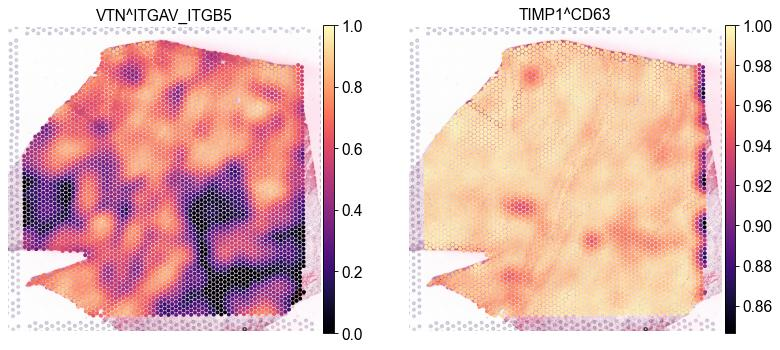

In [14]:
sc.pl.spatial(lrdata, color=['VTN^ITGAV_ITGB5', 'TIMP1^CD63'], size=1.4, vmax=1, cmap='magma')

As expected, we see that the **TIMP1 & CD63** interaction is uniformly distributed across the slide, while **VTN&ITGAV_ITGB5** shows a clear spatial pattern.

We can also see that this is the case when we look at the individual genes:

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/473169860.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.


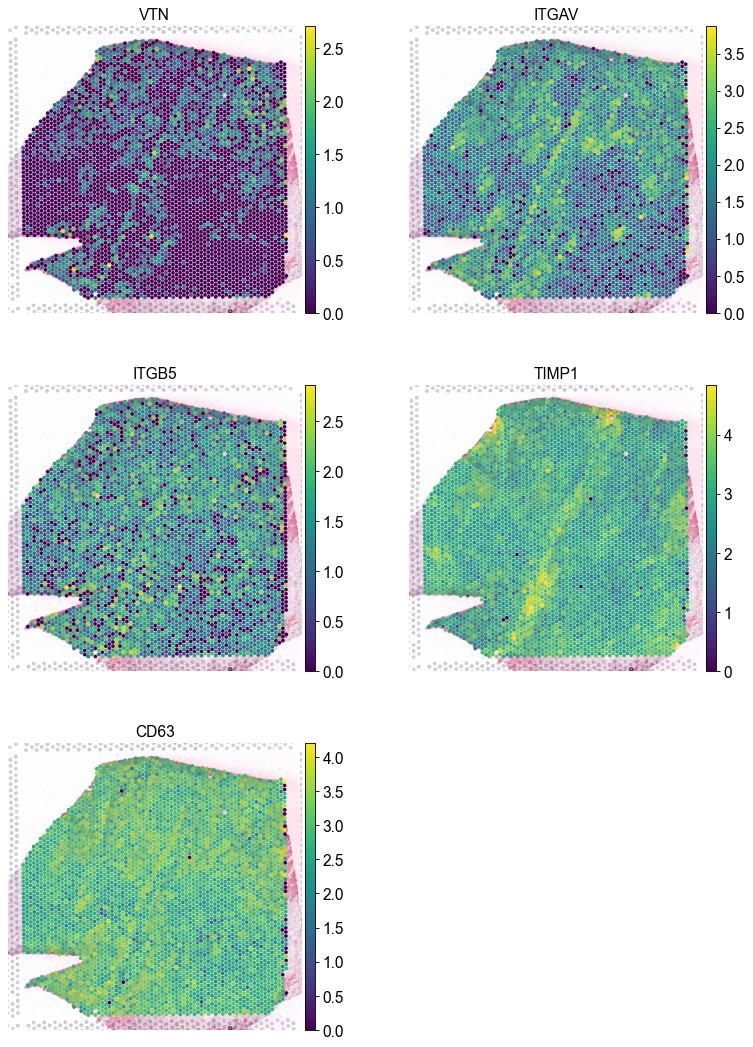

In [15]:
sc.pl.spatial(adata, color=['VTN', 'ITGAV', 'ITGB5', 
                            'TIMP1', 'CD63'],
              size=1.4, ncols=2)

<div class="alert alert-info">
  While Moran's R provides a sound summary of spatial clustering, it is limited to two variables at a time and is thus not fit for complex, or non-linear, spatial relationships between variables. Thus, we also encourage the user to explore <a href="https://liana-py.readthedocs.io/en/latest/notebooks/misty.html">LIANA+'s re-implementation of MISTy</a>.
</div>




### Permutation-based p-values
In addition to the local scores, we also calculated permutation-based p-values based on a null distribution generated by shuffling the spot labels. Let's see how these look for the two interactions from above: 

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/3589401274.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.


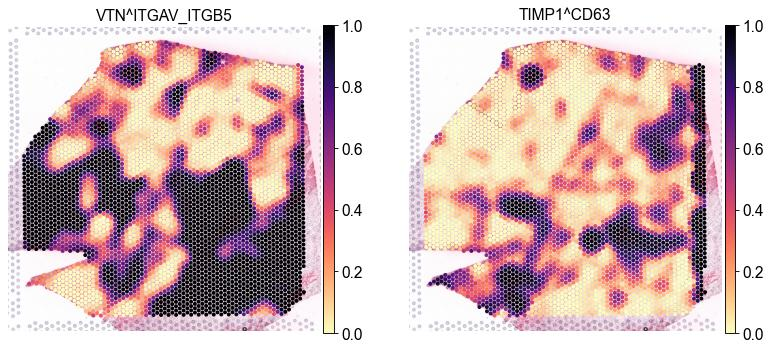

In [16]:
sc.pl.spatial(lrdata, layer='pvals', color=['VTN^ITGAV_ITGB5', 'TIMP1^CD63'], size=1.4, cmap="magma_r")

These largely agree with what we saw above for *VTN&ITGAV_ITGB5*, which appears to be specific to a certain region.

### Local Categories

Did you notice that we used `mask_negatives` as a parameter when first estimating the interaction? This essentially means that we mask interactions in which both members are negative (or lowly expressed) when calculating the p-values, i.e. such which occur at places in which both members of the interaction are highly expressed. The locations at which both members are highly- expressed is defined as follows:

For each interaction, we define the category of both **x** and **y** for each spot as follows:

$$ Category_i(x) = \begin{cases} \text{positive} & \text{if } \sum_{i,j} (x_i \cdot w_{ij}) > 0 \\ \text{negative} & \text{if } \sum_{i,j} (x_i \cdot w_{ij}) < 0 \\ \text{neither} & \text{otherwise} \end{cases}$$

Then we combine the categories of **x** and **y** for each spot, such that high-high are positive (1), high-low (or low-high) are -1; and low-low are 0.
When working with non-negative values (i.e. gene expression); the features will be z-scaled (across observations).

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/512657186.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.


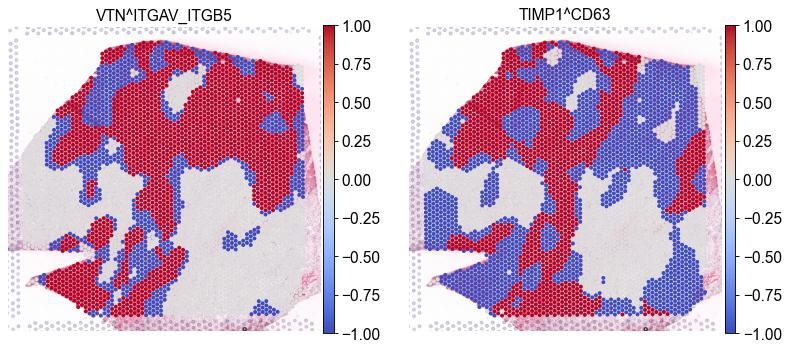

In [17]:
sc.pl.spatial(lrdata, layer='cats', color=['VTN^ITGAV_ITGB5', 'TIMP1^CD63'], size=1.4, cmap="coolwarm")

Here, we can distinguish areas in which the interaction between interaction members is positive (high-high) in Red (1), while interactions in which one is high the other is low or negative (High-low) are in Blue (-1). We also see that some interactions are neither, these are predominantly interactions in which both members are lowly-expressed (i.e. low-low); we see those in white (0).

When set to `mask_negatives=False`, we also return interactions that are not between necessarily positive/high magnitude genes ; when set to `mask_negatives=True`, we mask interactions that are negative (low-low) or uncategorized; for both the p-values and the local scores.

## Identify Intercellular Patterns

Now that we have estimated ligand-receptor scores, we can use non-negative matrix factorization (NMF) to identify coordinated cell-cell communication signatures.
This would ultimately decompose the ligand-receptor scores into a basis matrix (`W`) and a coefficient matrix (`H`). We will use a very simple utility function (around sklearn's NMF implementation) to do so, along with a simple `k` (component number) selection procedure.

* Basis Matrix (`W`):
        Each basis vector represents a characteristic pattern of ligand-receptor expression in the dataset.
        The values in `W` (factor score) indicate the strengths of factor in each spot; high values indicate high influence by the associated communication signature, while low values mean a weak influence.
* Coefficient Matrix (`H`):
        Each row of `H` represents the participation of the corresponding sample in the identified factor.
        The elements of each basis vector indicate the contribution of different interactions to the pattern (factor).

<img src="nmf.png" width=700 />


By decomposing the ligand-receptor interactions into W and H, NMF can potentially identify underlying CCC processes, with additive and non-negative relationships between the features. This property aligns well with the biological intuition that genes work together in a coordinated manner, but assumes linearity and only captures additive effects. Thus, alternative decomposition or clustering approaches can be used to a similar end. 

In this particular scenario, we chose NMF as it is a well-established method for decomposition of non-negative matrices, it is fast, and it is easy to interpret. Also, in our case the ligand-receptor local scores already encode the spatial relationships between the features, so we don't necessarily need to use a spatial-aware decomposition methods (e.g. [SpatialDE](https://www.nature.com/articles/nmeth.4636), [Spatial NMF](https://www.nature.com/articles/s41592-022-01687-w), [Chrysalis](https://github.com/rockdeme/chrysalis), or [MEFISTO](https://www.nature.com/articles/s41592-021-01343-9)).

One limitation of NMF is that it requires the number of components (factors) to be specified - a somewhat an arbitrary choice. To aid the selection of `n_components`, we provide a simple function that estimates an elbow based on reconstruction error.  Another limitation is that it only accepts non-negative values, so it won't work with metrics that can be negative (e.g. Pearson correlation). In this case, we use Cosine similarity with non-negative values, which results also in non-negative local scores.

In [18]:
li.ms.nmf(lrdata, n_components=None, inplace=True, random_state=0, max_iter=200, verbose=True)

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
 10%|█         | 1/10 [00:00<00:08,  1.02it/s]

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
 20%|██        | 2/10 [00:02<00:10,  1.34s/it]

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
 30%|███       | 3/10 [00:05<00:13,  1.86s/it]

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
 40%|████      | 4/10 [00:08<00:14,  2.33s/it]

...

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
 90%|█████████ | 9/10 [00:36<00:06,  6.11s/it]

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
100%|██████████| 10/10 [00:41<00:00,  5.78s/it]

100%|██████████| 10/10 [00:41<00:00,  4.17s/it]


Estimated rank: 3


/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.


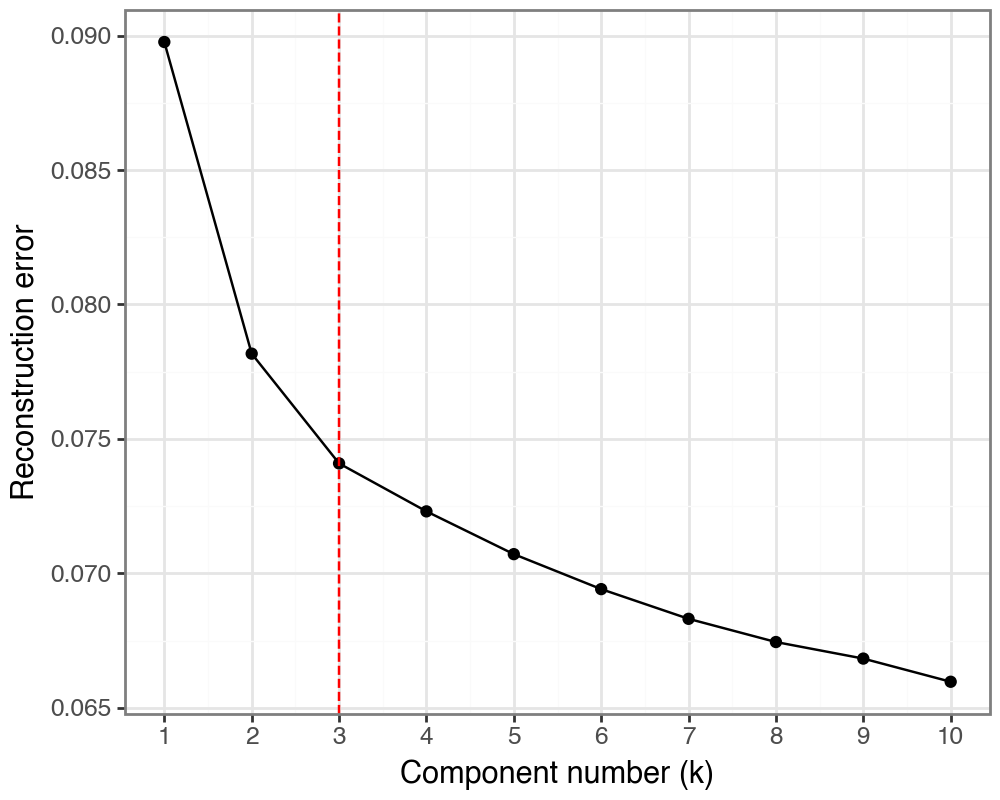

In [19]:
li.pl.elbow(lrdata, figure_size=(5, 4))

In [20]:
# Extract the variable loadings
lr_loadings = li.ms.get_variable_loadings(lrdata, varm_key='NMF_H').set_index('index')

In [21]:
# Extract the factor scores
factor_scores = li.ms.get_factor_scores(lrdata, obsm_key='NMF_W')

Convert NMF Factor scores to an AnnData object for plotting

In [22]:
nmf = sc.AnnData(X=lrdata.obsm['NMF_W'],
                 obs=lrdata.obs,
                 var=pd.DataFrame(index=lr_loadings.columns),
                 uns=lrdata.uns,
                 obsm=lrdata.obsm)

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/4151407476.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.


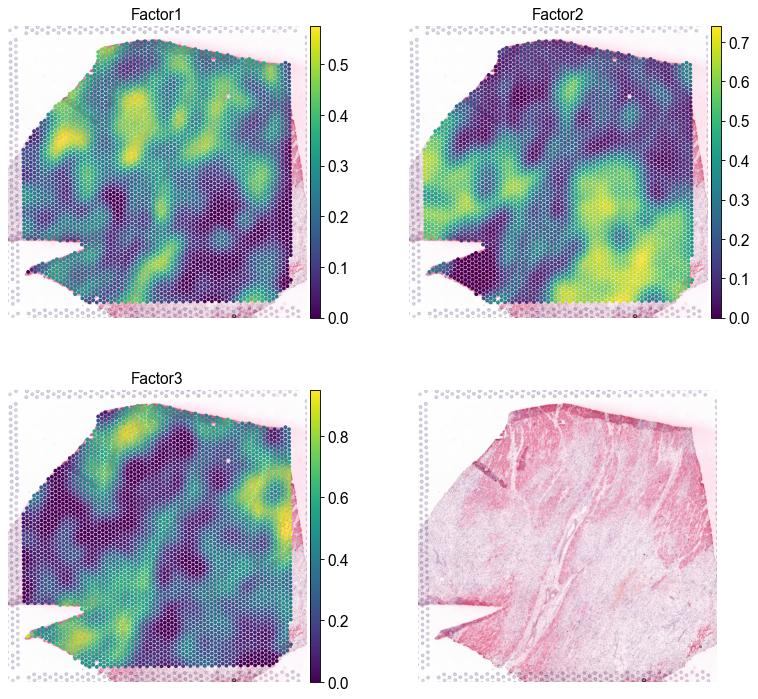

In [23]:
sc.pl.spatial(nmf, color=[*nmf.var.index, None], size=1.4, ncols=2)

Wee see that Factor 2 is largely covering the ischemic areas of the side, let's check the interactions contributing the most to it:

In [24]:
lr_loadings.sort_values("Factor2", ascending=False).head(10)

,Factor1,Factor2,Factor3
index,,,
APOE^LRP1,1.301640,1.277511,0.314723
MDK^LRP1,1.424604,1.208294,0.373204
C3^LRP1,0.861046,1.197814,0.176561
SERPING1^LRP1,1.533593,1.184904,0.552795
VCAN^ITGB1,1.528515,1.164363,0.655840
C3^CD81,0.742806,1.164204,0.228809
C1QB^LRP1,1.506625,1.162395,0.559758
PSAP^LRP1,1.571943,1.156679,0.680573
FBN1^ITGB1,1.530809,1.147668,0.701890


<div class="alert alert-info">
  From here on, one can estimate pathway activities or look for downstream effects of these interactions, plot the interactions, etc. These utility functions in liana are covered in other tutorials, but also applicable here.
</div>

## Beyond Ligand-Receptors

While protein-mediated ligand-receptor interactions are interesting, cell-cell communication is not limited to those alone. Rather it is a complex process that involves a variety of different mechanisms such as signalling pathways, metabolite-mediated signalling, and distinct cell types.

So, if such diverse mechanisms are involved in cell-cell communication, why should we limit ourselves to ligand-receptor interactions?
Let's see how we can use LIANA+ to explore other types of cell-cell communication.

One simple approach would be to check relationships e.g. between transcription factors and cell type proportions.

### Extract Cell type Composition
This slide comes with estimated cell type proportions using cell2location; See [Kuppe et al., 2022](https://www.nature.com/articles/s41586-022-05060-x). Let's extract from .obsm them to an independent AnnData object.

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/23732867.py:4: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.


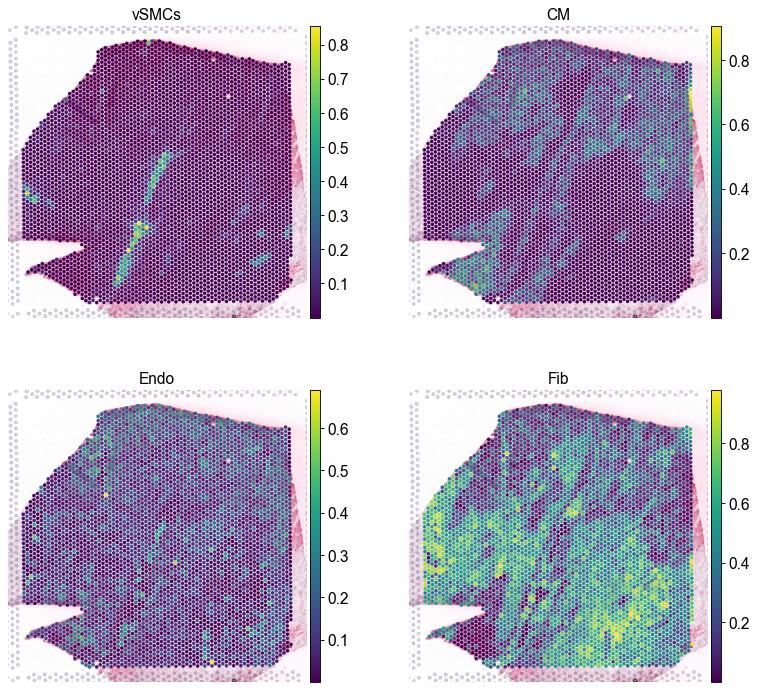

In [25]:
# let's extract those
comps = li.pp.obsm_to_adata(adata, 'compositions')
# check key cell types
sc.pl.spatial(comps, color=['vSMCs','CM', 'Endo', 'Fib'], size=1.3, ncols=2)

### Estimate Transcription Factor Activity

In [26]:
# Get transcription factor resource
net = dc.op.collectri(organism='human', remove_complexes=False, license='academic', verbose=False)

While multi-omics datasets might be even more of an interest, for the sake of simplicity (and because the general lack of spatial mutli-omics data at current times), let's instead use enrichment analysis to estimate the activity of transcription factors in each spot. We will use one of [decoupler-py's](https://decoupler-py.readthedocs.io/en/latest/index.html) enrichment methods with [CollectTRI](https://www.biorxiv.org/content/10.1101/2023.03.30.534849v1.abstract) to do so. Refer to this [tutorial](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_sc.html) for more info.

In [27]:
# run enrichment
dc.mt.ulm(adata, net=net, raw=False, verbose=True)

2026-09-07 12:03:02 | [INFO] ulm - Running ulm


ulm - Running ulm


2026-09-07 12:03:02 | [INFO] Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


2026-09-07 12:03:02 | [INFO] Network adjacency matrix has 5228 unique features and 693 unique sources


...

100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


2026-09-07 12:03:03 | [INFO] ulm - adjusting p-values by FDR


ulm - adjusting p-values by FDR


2026-09-07 12:03:03 | [INFO] ulm - done


ulm - done


#### Extract highly-variable TF activities
To reduce the number of TFs for the sake of computational speed, we will only focus on the top 50 most variable TFs.

Note we will use the simple coefficient of variation to identify the most variable TFs, but one can also use more sophisticated or spatially-informed methods to extract those (light-weight suggestions are welcome).


In [28]:
est = li.pp.obsm_to_adata(adata, 'score_ulm')
est.var['cv'] =  est.X.std(axis=0) / est.X.mean(axis=0)
top_tfs = est.var.sort_values('cv', ascending=False, key=abs).head(50).index


Create MuData object with TF activities and cell type proportions, and transfer spatial connectivities and other information from the original AnnData object.

In [29]:
mdata = MuData({"tf":est, "comps":comps})
mdata.obsp = adata.obsp
mdata.uns = adata.uns
mdata.obsm = adata.obsm

Define Interactions of interest:

In [30]:
from itertools import product

In [31]:
interactions = list(product(comps.var.index, top_tfs))

### Estimate Cosine Similarity

In [32]:
bdata = li.mt.bivariate(mdata,
                        x_mod="comps",
                        y_mod="tf",
                        x_transform=sc.pp.scale,
                        y_transform=sc.pp.scale,
                        local_name="cosine", 
                        interactions=interactions,
                        mask_negatives=True, 
                        add_categories=True,
                        x_use_raw=False,
                        y_use_raw=False,
                        xy_sep="<->",
                        x_name='celltype',
                        y_name='tf'
                        )

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.


<div class="alert alert-info">

To make the distributions comparable, we simply z-scale the TF activities and cell type proportions via the `x_transform` & `y_transform` parameters.

The type of transformation will affect the interpretation of the results, and different types of transformation might be more appropriate for different types of data. We provide zero-inflated minmax `zi_minmax` & `neg_to_zero` transformation functions via `li.pp`.

One can explore how different transformations affect the results, to also get a better feeling how these local metrics work.

</div>

In [33]:
bdata.var.sort_values("mean", ascending=False).head(5)

,celltype,tf,celltype_means,celltype_props,tf_means,tf_props,mean,std
interaction,,,,,,,,
CM<->TBX20,CM,TBX20,-6.781192e-09,1.0,1.455919e-08,1.0,0.619449,0.161595
Fib<->SNAI2,Fib,SNAI2,1.338776e-08,1.0,4.212779e-09,1.0,0.563574,0.194298
Fib<->SOX6,Fib,SOX6,1.338776e-08,1.0,6.606570e-09,1.0,0.505218,0.246272
Myeloid<->TBX21,Myeloid,TBX21,9.822543e-09,1.0,-7.457857e-11,1.0,0.494373,0.161925
Myeloid<->SNAI2,Myeloid,SNAI2,9.822543e-09,1.0,4.212779e-09,1.0,0.459984,0.220001


#### Let's plot the results

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_75621/1870980248.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
... storing 'celltype' as categorical


... storing 'tf' as categorical


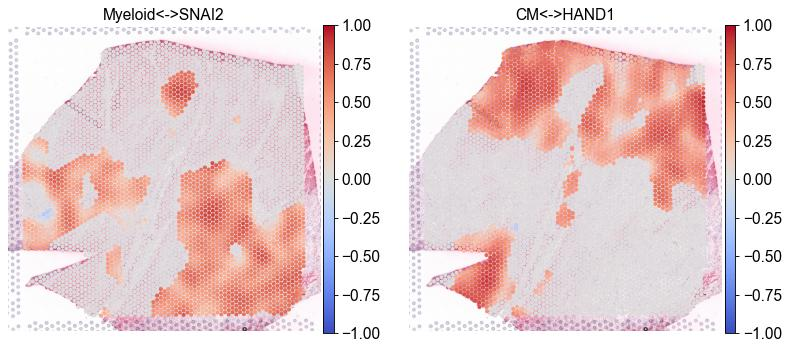

In [34]:
sc.pl.spatial(bdata, color=['Myeloid<->SNAI2', 'CM<->HAND1'], size=1.4, cmap="coolwarm", vmax=1, vmin=-1)